In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:

    sys.path.append(module_path)

In [17]:
import json
import numpy as np
import pandas as pd
import trackpy as tp
import seaborn as sns
import matplotlib.pyplot as plt

from cmcrameri import cm
from scipy.optimize import curve_fit
from scipy.stats import linregress, chisquare

from src.HolomonitorFunctions import get_pixel_size
from VertexModelFunctions import *

In [4]:
pix_to_um = get_pixel_size()
holo_dict = json.load(open("../../data/Holomonitor/settings.txt"))

dataset = 1
path = holo_dict["files"][dataset]
fmin = holo_dict["fmin"][dataset]
fmax = holo_dict["fmax"][dataset]
file = path.split("/")[-1]
dir  = path.split(file)[0]

#stack = import_holomonitor_stack(dir, file, f_min=fmin, f_max=fmax)
df = pd.read_csv(f"{path}/area_volume_unfiltered.csv")
print(file)

colors = cm.roma_r(np.linspace(0, 1, len(holo_dict["files"])))

A1-9


In [ ]:
time = []
MSD  = []
dr = []
density = []
r_arr = []

for dataset in range(len(holo_dict['files'])):
    path = holo_dict["files"][dataset]
    df = pd.read_csv(f"{path}/area_volume_unfiltered.csv")

    # track and sort tracks
    tracks = tp.link(df, search_range=10, memory=5)
    tracks = tp.filter_stubs(tracks, 5)

    MSD_arr, frame_MSD = [], []
    dr_arr,  frame_dr  = [], []

    # run through cells in frame
    for p in np.unique(tracks.particle):
        tmp = tracks[tracks.particle==p]

        frame_MSD.append(np.arange(len(tmp)))
        frame_dr.append(tmp.frame.values[1:])

        # calculate MSD and dr
        MSD_arr.append((tmp.x.values-tmp.x.values[0])**2 + (tmp.y.values-tmp.y.values[0])**2)
        dr_arr.append(np.sqrt(np.diff(tmp.x.values)**2 + np.diff(tmp.y.values)**2))

    # add to list
    frame_MSD  = np.concatenate(frame_MSD)
    frame_dr = np.concatenate(frame_dr)
    MSD_arr  = np.concatenate(MSD_arr)
    dr_arr = np.concatenate(dr_arr)

    # take mean
    time.append(np.unique(tracks.frame) / 12)
    dr.append(np.array([np.mean(dr_arr[frame_dr == f]) for f in range(np.max(tracks.frame)+1)]) * pix_to_um[0])

    MSD_tmp = [np.mean(MSD_arr[frame_MSD == f]) for f in range(np.max(tracks.frame)+1)]
    MSD.append(np.array(MSD_tmp) * pix_to_um[0]**2)

    density.append(np.array([np.sum(df.frame == f) / np.sum(df[df.frame == f].A) for f in range(np.max(tracks.frame)+1)])*10**6)
    #density.append(np.array([hexagon_area(np.mean(df[df.frame==f].V)) / np.mean(df[df.frame==f].A)   for f in range(np.max(tracks.frame)+1)]))
    r_arr.append(np.array([hexagon_area(np.mean(df[df.frame == f].V)) / np.mean(df[df.frame == f].A) for f in range(np.max(tracks.frame)+1)]))

Frame 144: 825 trajectories present.


/home/silja/Programs/miniconda3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/silja/Programs/miniconda3/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


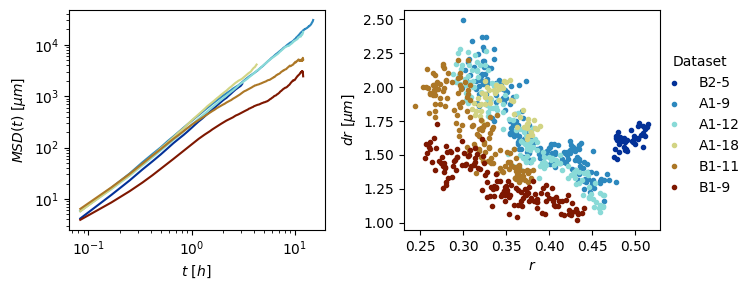

In [ ]:
# scale to correct unit
# dr  = np.array(dr) * pix_to_um[0]
# MSD = MSD * pix_to_um[0]*pix_to_um[1] 
# time    = time / 12    #h
# density = density * 10**6 # 1/mm²

def func(time, a, b):
    return b*time**a

frame = 12
fig, ax = plt.subplots(1,2, figsize=(8,3))

for i in range(len(holo_dict["files"])):
    path = holo_dict["files"][i]
    ax[0].plot(time[i][1:], MSD[i][1:], '-', c=colors[i])
    ax[1].plot(density[i],  dr[i],      '.', c=colors[i], label=path.split("/")[-1])

    param, popt = curve_fit(func, time[i][1:frame], MSD[i][1:frame])
    #ax[0].plot(time[i][1:], func(time[i][1:], *param), c=colors[i])
    #print(param[0])

    param, popt = curve_fit(func, time[i][1:frame], MSD[i][1:frame])
    #ax[0].plot(time[i][1:], func(time[i][1:], *param), c=colors[i])
ax[0].set(xscale="log", yscale="log")
ax[0].set(xlabel=r"$t ~[h]$", ylabel=r"$MSD(t) ~[µm]$")
ax[1].set(xlabel=r"$\rho_{cell} ~[mm^{-2}]$", ylabel=r"$dr ~[µm]$")

fig.tight_layout(rect=[0,0,0.85,1])
ax[1].legend(title="Dataset", bbox_to_anchor=(0.95, 0.85), frameon=False, alignment='center')

In [98]:
fig.savefig("../../figs/vertex_model/MSD_dr_r.png", dpi=300)